In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model


In [3]:
df = yf.download('AAPL', start='2018-01-01', end='2023-12-31',auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341885,40.351254,39.639309,39.850084,102223600
2018-01-03,40.334866,40.878192,40.271636,40.405124,118071600
2018-01-04,40.522217,40.625262,40.299735,40.407462,89738400
2018-01-05,40.983578,41.070228,40.526904,40.618239,94640000
2018-01-08,40.831341,41.126421,40.732977,40.831341,82271200


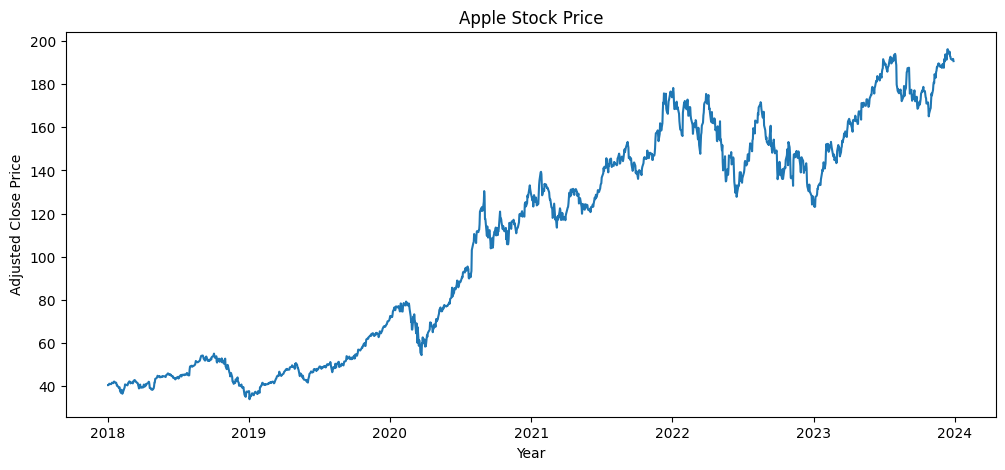

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(df['Close'])
plt.title("Apple Stock Price")
plt.xlabel("Year")
plt.ylabel("Adjusted Close Price")
plt.show()

In [5]:
# Create log prices (better for ARIMA because stock prices grow exponentially)
df['log_price'] = np.log(df['Close'])

# Create log returns (required for GARCH)
df['log_return'] = df['log_price'].diff()

# Drop missing values from differencing
df.dropna(inplace=True)


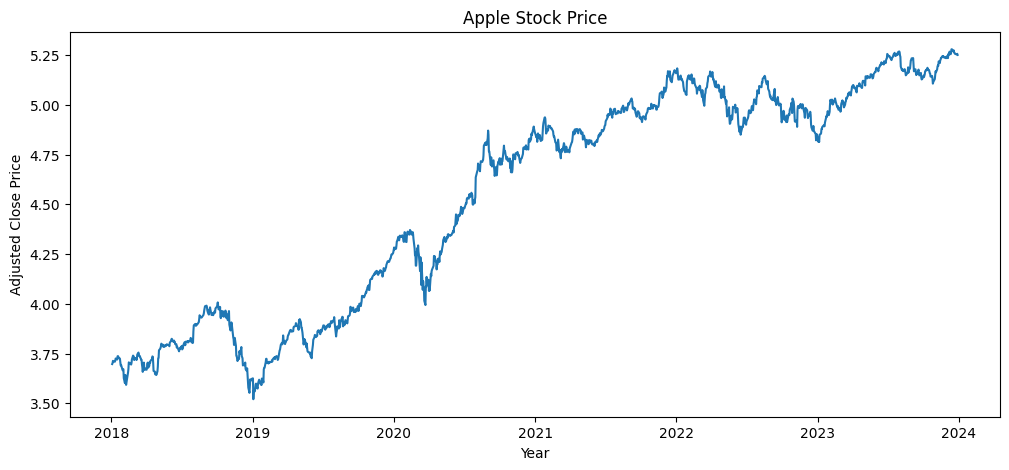

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df['log_price'])
plt.title("Apple Stock Price")
plt.xlabel("Year")
plt.ylabel("Adjusted Close Price")
plt.show()


In [7]:
# ARIMA(1,1,1) model on log prices
arima_model = ARIMA(df['log_price'], order=(1,1,1))
arima_result = arima_model.fit()

print(arima_result.summary())


c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              log_price   No. Observations:                 1508
Model:                 ARIMA(1, 1, 1)   Log Likelihood                3764.890
Date:                Mon, 15 Dec 2025   AIC                          -7523.779
Time:                        17:19:03   BIC                          -7507.826
Sample:                             0   HQIC                         -7517.837
                               - 1508                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0861      0.165     -0.523      0.601      -0.409       0.237
ma.L1         -0.0116      0.169     -0.068      0.945      -0.342       0.319
sigma2         0.0004   8.54e-06     46.373      0.0

In [8]:
!pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(
    df['log_price'],
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-7522.710, Time=1.03 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-7515.400, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-7528.672, Time=0.32 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-7528.684, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-7513.387, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-7526.707, Time=0.53 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-7526.703, Time=0.60 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-7524.703, Time=1.28 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-7525.694, Time=0.18 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 4.566 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1508
Model:               SARIMAX(0, 1, 1)   Log Likelihood                3767.342
Date:                Mon, 15 Dec 2025   

In [9]:
# Forecast 10 future time steps
forecast_steps = 10

# Forecast log prices
log_forecast = arima_result.forecast(steps=forecast_steps)

# Convert log prices back to actual prices
price_forecast = np.exp(log_forecast)




c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


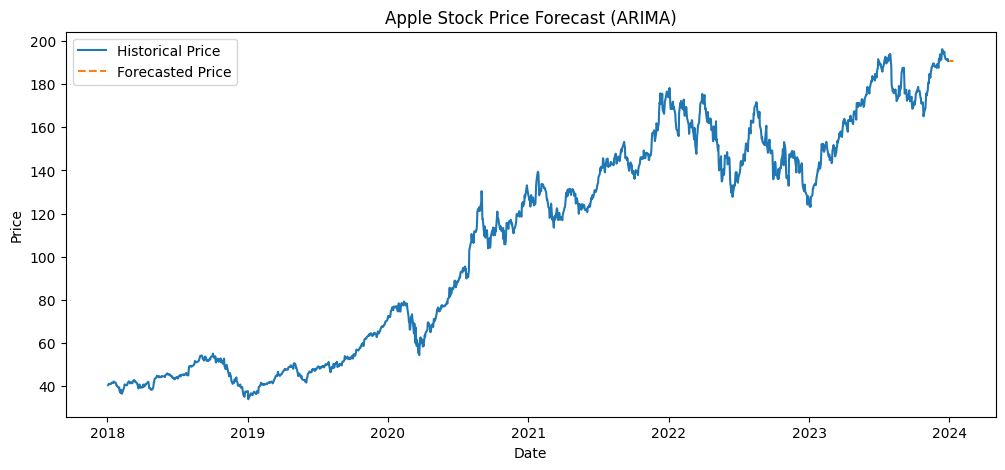

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Historical Price')

# Plot forecast
future_index = pd.date_range(start=df.index[-1], periods=forecast_steps+1, freq='B')[1:]
plt.plot(future_index, price_forecast, label='Forecasted Price', linestyle='--')

plt.title("Apple Stock Price Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [11]:
# Fit GARCH(1,1) model on log returns
garch = arch_model(df['log_return'], vol='GARCH', p=1, q=1)
garch_result = garch.fit()

print(garch_result.summary())


c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003983. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Iteration:      1,   Func. Count:      6,   Neg. LLF: 7.872774533246045e+19
Iteration:      2,   Func. Count:     18,   Neg. LLF: 5033022583.781462
Iteration:      3,   Func. Count:     30,   Neg. LLF: 88729383554.50975
Iteration:      4,   Func. Count:     43,   Neg. LLF: 743988032.9092482
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3933.8119457628654
            Iterations: 4
            Function evaluations: 53
            Gradient evaluations: 4
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3933.81
Distribution:                  Normal   AIC:                          -7859.62
Method:            Maximum Likelihood   BIC:                          -7838.35
                         

In [12]:
# Forecast horizon
vol_forecast = garch_result.forecast(horizon=10)

# Extract conditional volatility (daily std deviation)
daily_vol_forecast = np.sqrt(vol_forecast.variance.values[-1])
daily_vol_forecast


array([0.01058429, 0.01085145, 0.01110704, 0.01135194, 0.01158691,
       0.01181266, 0.01202978, 0.01223882, 0.01244027, 0.01263457])

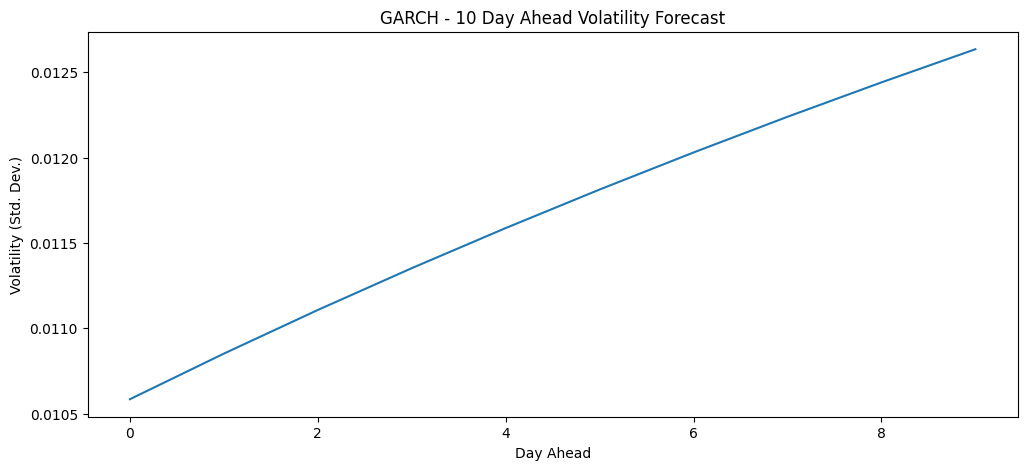

In [13]:
plt.figure(figsize=(12,5))
plt.plot(daily_vol_forecast)
plt.title("GARCH - 10 Day Ahead Volatility Forecast")
plt.xlabel("Day Ahead")
plt.ylabel("Volatility (Std. Dev.)")
plt.show()


C:\Users\Hassan\AppData\Local\Temp\ipykernel_5500\1417593560.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2010-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

Forecast with ±1σ confidence interval:
            Forecasted_Price  Lower_Bound  Upper_Bound
2024-01-01        190.770602   188.424757   193.145653
2024-01-02        190.768915   188.255271   193.316121
2024-01-03        190.768983   188.101290   193.474510
2024-01-04        190.768980   187.958664   193.621315
2024-01-05        190.768980   187.825733   193.758348
2024-01-08        190.768980   187.701170   193.886931
2024-01-09        190.768980   187.583931   194.008109
2024-01-10        190.768980   187.473181   194.122720
2024-01-11        190.768980   187.368231   194.231453
2024-01-12        190.768980   187.268513   194.334879


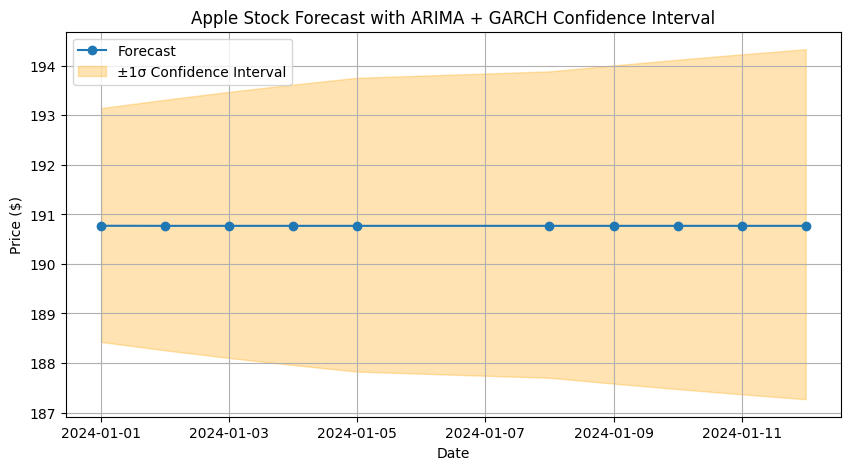

In [14]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import matplotlib.pyplot as plt

# Step 1: Download Apple stock data (if not already done)
df = yf.download("AAPL", start="2010-01-01", end="2024-01-01")

# Step 2: Create log prices
df['log_price'] = np.log(df['Close'])

# Step 3: Fit ARIMA on log prices (adjust order if needed)
# Here we use (1,1,1) as an example
arima_model = ARIMA(df['log_price'], order=(1,1,0))
arima_result = arima_model.fit()

# Step 4: Forecast next n steps (here, 10 days)
forecast_steps = 10
log_forecast = arima_result.forecast(steps=forecast_steps)  # ARIMA forecast (log prices)

# Step 5: Compute residuals from ARIMA to model volatility
residuals = arima_result.resid  # difference between actual and ARIMA fitted values

# Step 6: Fit GARCH(1,1) on ARIMA residuals to estimate volatility
# GARCH models variance (squared residuals)
garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp='off')  # disp='off' hides fitting output

# Step 7: Forecast volatility (standard deviation) for next n steps
garch_forecast = garch_result.forecast(horizon=forecast_steps)
# 'mean' is variance forecast; take square root to get standard deviation
forecast_volatility = np.sqrt(garch_forecast.variance.values[-1, :])

# Step 8: Convert ARIMA log forecast back to actual prices
price_forecast = np.exp(log_forecast)

# Step 9: Create confidence intervals using volatility
# ±1 standard deviation
upper_bound = np.exp(log_forecast + forecast_volatility)
lower_bound = np.exp(log_forecast - forecast_volatility)

# Step 10: Prepare forecast table
forecast_dates = pd.bdate_range(start=df.index[-1]+pd.Timedelta(days=1), periods=forecast_steps)
forecast_df = pd.DataFrame({
    'Forecasted_Price': price_forecast.values,
    'Lower_Bound': lower_bound.values,
    'Upper_Bound': upper_bound.values
}, index=forecast_dates)

print("Forecast with ±1σ confidence interval:")
print(forecast_df)

# Step 11: Optional - plot forecast with confidence intervals
plt.figure(figsize=(10,5))
plt.plot(forecast_df.index, forecast_df['Forecasted_Price'], label='Forecast', marker='o')
plt.fill_between(forecast_df.index, forecast_df['Lower_Bound'], forecast_df['Upper_Bound'], color='orange', alpha=0.3, label='±1σ Confidence Interval')
plt.title("Apple Stock Forecast with ARIMA + GARCH Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Hassan\AppData\Local\Temp\ipykernel_5500\902278622.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actual_future = yf.download("AAPL", start="2024-01-02", end="2024-03-01")  # adjust end if needed
[*********************100%***********************]  1 of 1 completed


Forecast Table with Actual Prices:
            Forecasted_Price  Lower_Bound  Upper_Bound  Actual_Close
Date                                                                
2024-01-02        190.770602   188.424757   193.145653    183.903244
2024-01-03        190.768915   188.255271   193.316121    182.526230
2024-01-04        190.768983   188.101290   193.474510    180.208130
2024-01-05        190.768980   187.958664   193.621315    179.484940
2024-01-08        190.768980   187.825733   193.758348    183.823990
2024-01-09        190.768980   187.701170   193.886931    183.407898
2024-01-10        190.768980   187.583931   194.008109    184.448074
2024-01-11        190.768980   187.473181   194.122720    183.853683
2024-01-12        190.768980   187.368231   194.231453    184.180603
2024-01-16        190.768980   187.268513   194.334879    181.912033


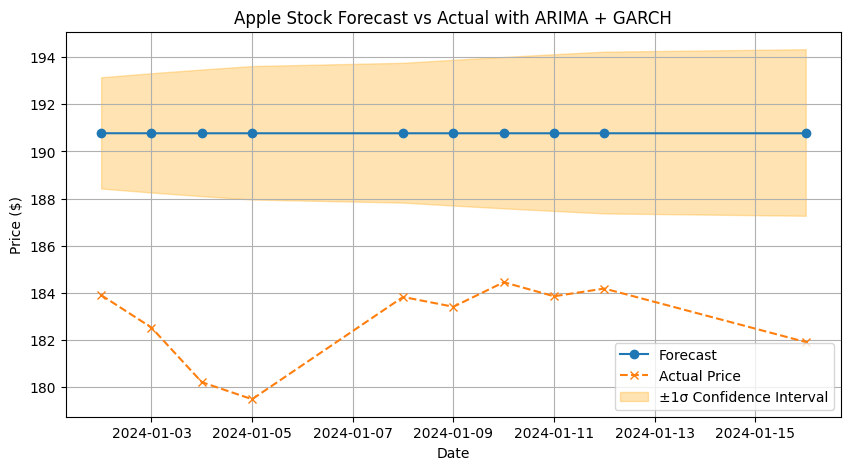

In [15]:
# Step 1: Download actual future Apple prices for comparison
actual_future = yf.download("AAPL", start="2024-01-02", end="2024-03-01")  # adjust end if needed

# Step 2: Take first 10 trading days
actual_future_10 = actual_future.head(forecast_steps)  # forecast_steps = 10
forecast_dates = actual_future_10.index

# Step 3: Prepare forecast DataFrame
forecast_df = pd.DataFrame({
    'Forecasted_Price': price_forecast.values,   # ARIMA point forecast
    'Lower_Bound': lower_bound.values,           # ARIMA ± GARCH volatility (lower)
    'Upper_Bound': upper_bound.values,           # ARIMA ± GARCH volatility (upper)
    'Actual_Close': actual_future_10['Close'].squeeze().values  # actual prices for comparison
}, index=forecast_dates)

print("Forecast Table with Actual Prices:")
print(forecast_df)

# Step 4: Plot forecast vs actual with confidence intervals
plt.figure(figsize=(10,5))
plt.plot(forecast_df.index, forecast_df['Forecasted_Price'], label='Forecast', marker='o')
plt.plot(forecast_df.index, forecast_df['Actual_Close'], label='Actual Price', marker='x', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['Lower_Bound'], forecast_df['Upper_Bound'], color='orange', alpha=0.3, label='±1σ Confidence Interval')
plt.title("Apple Stock Forecast vs Actual with ARIMA + GARCH")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Hassan\AppData\Local\Temp\ipykernel_5500\1229095154.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2010-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
c:\Users\Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003158. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Hassan\AppData\Local\Temp\ipykernel_5500\1229095154.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  future_df = yf.download("AAPL", start="2024-01-02", end="2024-01-16")

Forecast vs Realized Volatility for next 8 days:

        Date  Forecasted Volatility  Realized Volatility
0 2024-01-03               0.011763             0.007516
1 2024-01-04               0.011912             0.012781
2 2024-01-05               0.012058             0.004021
3 2024-01-08               0.012198             0.023887
4 2024-01-09               0.012334             0.002266
5 2024-01-10               0.012466             0.005655
6 2024-01-11               0.012594             0.003228
7 2024-01-12               0.012719             0.001777


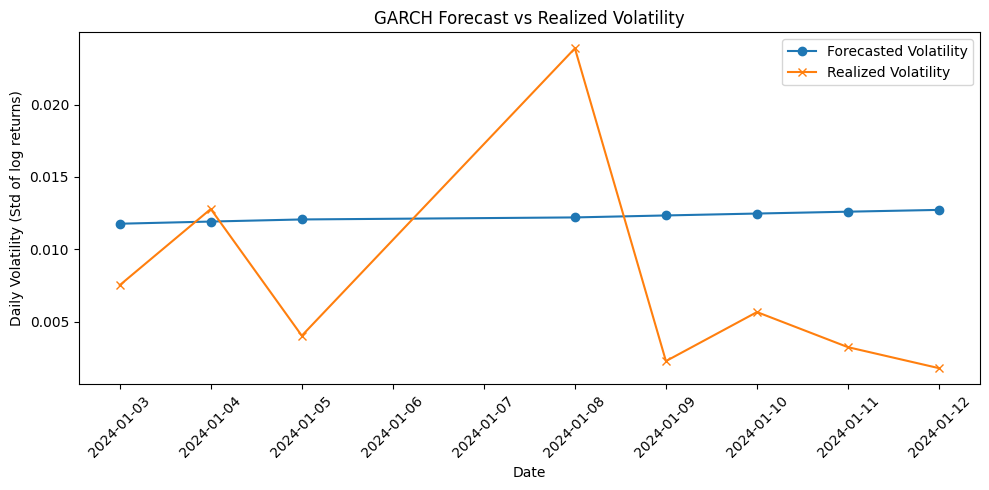


Mean Squared Error between forecast and realized volatility: 7.190310446894218e-05


In [16]:
from arch import arch_model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- Step 1: Download historical data ---
df = yf.download("AAPL", start="2010-01-01", end="2024-01-01")
df['log_price'] = np.log(df['Close'])
df['log_return'] = df['log_price'].diff()
df.dropna(inplace=True)

# --- Step 2: Fit GARCH(1,1) ---
garch = arch_model(df['log_return'], vol='GARCH', p=1, q=1)
garch_result = garch.fit(disp='off')

# --- Step 3: Forecast next 10 days ---
vol_forecast = garch_result.forecast(horizon=10)
daily_vol_forecast = np.sqrt(vol_forecast.variance.values[-1])

# --- Step 4: Download future 10 days of data ---
# The end date is 2024-01-16, which means it will download data up to and including 2024-01-15
# We need to account for weekends/holidays, so the actual number of days might be less than 10.
future_df = yf.download("AAPL", start="2024-01-02", end="2024-01-16")
future_df['log_price'] = np.log(future_df['Close'])
future_df['log_return'] = future_df['log_price'].diff()
future_df.dropna(inplace=True)

# --- Step 5: Calculate realized daily volatility ---
# Using absolute log return as a proxy for daily realized volatility for comparison
realized_vol = future_df['log_return'].abs().values

# Adjust the forecast length to match the available future data for comparison
forecast_horizon_actual = len(future_df)
adjusted_daily_vol_forecast = daily_vol_forecast[:forecast_horizon_actual]

# --- Step 6: Create side-by-side table ---
comparison_df = pd.DataFrame({
    'Date': future_df.index,
    'Forecasted Volatility': adjusted_daily_vol_forecast,
    'Realized Volatility': realized_vol
})

print("Forecast vs Realized Volatility for next {} days:\n".format(forecast_horizon_actual))
print(comparison_df)

# --- Step 7: Plot for visualization ---
plt.figure(figsize=(10,5))
plt.plot(comparison_df['Date'], comparison_df['Forecasted Volatility'], marker='o', label='Forecasted Volatility')
plt.plot(comparison_df['Date'], comparison_df['Realized Volatility'], marker='x', label='Realized Volatility')
plt.title("GARCH Forecast vs Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Volatility (Std of log returns)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Step 8: Compute Mean Squared Error ---
mse = mean_squared_error(comparison_df['Realized Volatility'], comparison_df['Forecasted Volatility'])
print("\nMean Squared Error between forecast and realized volatility:", mse)